### Introduction to Network Analysis 2025/26 (xvi)

# Selected analyses of networks

In [1]:
import networkx as nx

import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

PATH = "../nets"

def read(name, path = PATH):
    G = nx.DiGraph(name = name)
    with open(path + "/" + name + ".net", 'r') as file:
        file.readline()

        for line in file:
            if line.startswith("*"):
                break
            else:
                node = line.strip().split("\"")
                G.add_node(int(node[0]) - 1, label = node[1])

        for line in file:
            i, j = (int(x) - 1 for x in line.split()[:2])
            if i != j:
                G.add_edge(i, j)

    return G
  
def info(G):
    print("{:>12s} | '{:s}'".format('Graph', G.name))

    n = G.number_of_nodes()
    m = G.number_of_edges()
  
    print("{:>12s} | {:,d} ({:,d})".format('Nodes', n, nx.number_of_isolates(G)))
    print("{:>12s} | {:,d} ({:,d})".format('Edges', m, nx.number_of_selfloops(G)))
    print("{:>12s} | {:.2f} ({:,d})".format('Degree', 2 * m / n, max([k for _, k in G.degree()])))
    print()

### I. Bow-tie structure of the Web

Broder et al., [Graph structure in the Web](https://www.sciencedirect.com/science/article/pii/S1389128600000839), _Comput. Netw._ **33**(1-6), 309-320 (2000).

![](https://www.researchgate.net/profile/Debora-Donato-3/publication/200111010/figure/fig1/AS:285227383177216@1445014915124/The-bow-tie-structure-of-the-Web-graph.png)

In [2]:
G = read("www_google")

info(G)

WCCs = sorted(nx.weakly_connected_components(G), key = len)
SCCs = sorted(nx.strongly_connected_components(G), key = len)
OUT = set(nx.dfs_tree(G, next(iter(SCCs[-1]))).nodes()) - SCCs[-1]
IN = set(nx.dfs_tree(nx.reverse(G), next(iter(SCCs[-1]))).nodes()) - SCCs[-1]

print("{:>12s} | {:.1f}%".format('WCC', 100 * len(WCCs[-1]) / len(G)))
print("{:>12s} | {:.1f}% ({:.1f}%)".format('SCC', 100 * len(SCCs[-1]) / len(G), 100 * len(SCCs[-1]) / len(WCCs[-1])))
print("{:>12s} | {:.1f}% ({:.1f}%)".format('OUT', 100 * len(OUT) / len(G), 100 * len(OUT) / len(WCCs[-1])))
print("{:>12s} | {:.1f}% ({:.1f}%)".format('IN', 100 * len(IN) / len(G), 100 * len(IN) / len(WCCs[-1])))

       Graph | 'www_google'
       Nodes | 875,713 (0)
       Edges | 5,105,039 (0)
      Degree | 11.66 (6,353)

         WCC | 97.7%
         SCC | 49.7% (50.8%)
         OUT | 18.9% (19.4%)
          IN | 20.7% (21.1%)


### II. Densification law and shrinking diameters

Leskovec et al., [Graph evolution: Densification and shrinking diameters](https://dl.acm.org/doi/10.1145/1217299.1217301), _ACM Trans. Knowl. Discov. Data_ **1**(1), 2 (2007).

       Graph | 'aps_2001_2003'
       Nodes | 14,902 (0)
       Edges | 29,747 (0)
      Degree | 3.99 (69)

       Graph | 'aps_2001_2004'
       Nodes | 25,962 (0)
       Edges | 59,674 (0)
      Degree | 4.60 (90)

       Graph | 'aps_2001_2005'
       Nodes | 38,264 (0)
       Edges | 100,684 (0)
      Degree | 5.26 (125)

       Graph | 'aps_2001_2006'
       Nodes | 50,150 (0)
       Edges | 148,763 (0)
      Degree | 5.93 (192)

       Graph | 'aps_2001_2007'
       Nodes | 61,989 (0)
       Edges | 202,153 (0)
      Degree | 6.52 (234)

       Graph | 'aps_2001_2008'
       Nodes | 74,657 (0)
       Edges | 268,394 (0)
      Degree | 7.19 (269)

       Graph | 'aps_2001_2009'
       Nodes | 86,972 (0)
       Edges | 339,513 (0)
      Degree | 7.81 (293)

       Graph | 'aps_2001_2010'
       Nodes | 99,892 (0)
       Edges | 420,906 (0)
      Degree | 8.43 (319)

       Graph | 'aps_2001_2011'
       Nodes | 113,255 (0)
       Edges | 508,577 (0)
      Degree | 8.98 (342)

    

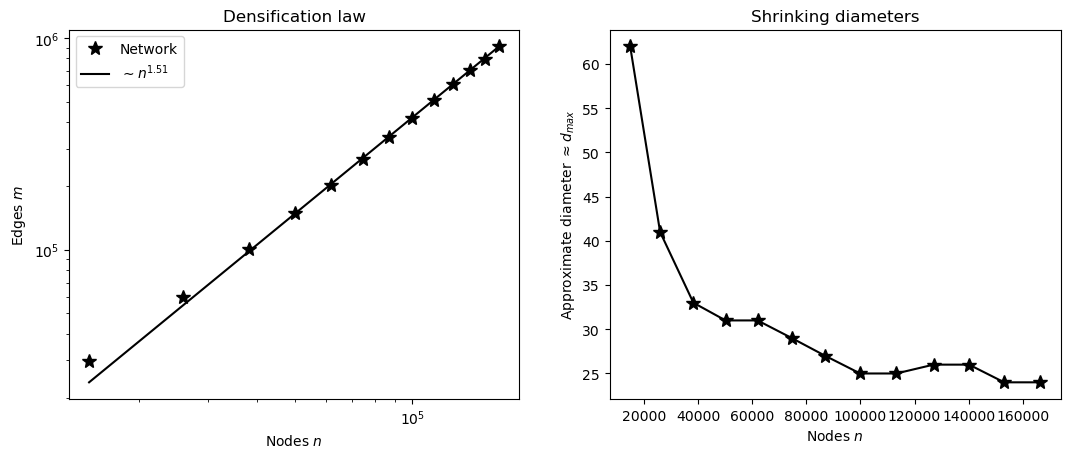

In [3]:
def lcc(G):
    return G.subgraph(max(nx.connected_components(G), key = len))

def diameter(G):
    D = nx.single_source_shortest_path_length(G, max(G.degree, key = lambda item: item[1])[0])
    for _ in range(10):
        D = nx.single_source_shortest_path_length(G, max(D, key = D.get))
    return max(D.values())

APS = read("aps_2001_2015")

Gs = []
for year in range(2003, 2016):
    G = lcc(nx.Graph(APS.subgraph(i for i in APS.nodes() if int(APS.nodes[i]['label'][-5:-1]) <= year)))
    G.name = "aps_2001_" + str(year)
    Gs.append(G)
 
    info(G)

ns = [len(G) for G in Gs]
ms = [G.number_of_edges() for G in Gs]

law = lambda n, a, c: c * n**a
(a, c), _ = curve_fit(law, ns, ms)

fig, axs = plt.subplots(1, 2, figsize = [12.8, 4.8])

axs[0].loglog(ns, ms, '*k', markersize = 10, label = "Network")
axs[0].loglog(range(ns[0], ns[-1], 100), [law(n, a, c) for n in range(ns[0], ns[-1], 100)], '-k', label = r"$\sim n^{" + str(round(a, 2)) + "}$")
axs[0].title.set_text("Densification law")
axs[0].set_ylabel(r"Edges $m$")
axs[0].set_xlabel(r"Nodes $n$")
axs[0].legend()

axs[1].plot(ns, [diameter(G) for G in Gs], '-*k', markersize = 10)
axs[1].title.set_text("Shrinking diameters")
axs[1].set_ylabel(r"Approximate diameter $\approx d_{max}$")
axs[1].set_xlabel(r"Nodes $n$")

fig.savefig(PATH + "/" + APS.name + ".pdf", bbox_inches = 'tight')

### III. Robustness of European land transportation

Suppose you control an air fleet of $15$ heavy bombers, each of which can completely destroy an entire European city. Your goal is to cripple the European land transportation as much as possible by targeting $15$ key cities. In particular, you would like that the largest connected component of the remaining highways network connects less than $50$\% of cities. (Note that the network is not scale-free, so targeting the hubs won't be very effective.)

In [4]:
def LCC(G):
    return len(max(nx.connected_components(G), key = len))

def greedy_centrality(G):
    GC = {}
    for i in G.nodes():
        g = G.copy()
        g.remove_node(i)
        GC[i] = 1 - LCC(g) / len(G)
    return GC

G = nx.Graph(read("europe"))

info(G)

MEASURES = {"degree": nx.degree_centrality, "pagerank": nx.pagerank, "closeness": nx.closeness_centrality, "betweenness": nx.betweenness_centrality, "greedy": greedy_centrality}

for measure in MEASURES:
    print("{:>12s} | '{:s}'".format('Measure', measure))

    g = G.copy()
    for _ in range(15):
        i = max(MEASURES[measure](g).items(), key = lambda item: item[1])[0]
        label = g.nodes[i]['label']
        g.remove_node(i)
  
        print("{:>11.1f}% | '{:s}'".format(100 * LCC(g) / len(g), label))
    print()

       Graph | 'europe'
       Nodes | 1,039 (0)
       Edges | 1,305 (0)
      Degree | 2.51 (10)

     Measure | 'degree'
       99.9% | 'Moscow'
       99.9% | 'Berlin'
       99.9% | 'Munich'
       99.9% | 'Budapest'
       99.9% | 'Liège'
       99.9% | 'Paris'
       99.9% | 'Prague'
       99.7% | 'Vienna'
       99.7% | 'Warsaw'
       99.7% | 'Metz'
       99.4% | 'Innsbruck'
       99.0% | 'Bratislava'
       98.2% | 'Zagreb'
       97.2% | 'Larissa'
       97.1% | 'Riga'

     Measure | 'pagerank'
       99.9% | 'Moscow'
       99.9% | 'Berlin'
       99.9% | 'Budapest'
       99.9% | 'Liège'
       99.9% | 'Munich'
       99.9% | 'Paris'
       99.5% | 'Bratislava'
       98.4% | 'Larissa'
       98.2% | 'Innsbruck'
       98.2% | 'Prague'
       98.2% | 'Metz'
       97.2% | 'İzmir'
       96.1% | 'Malmö'
       96.1% | 'Warsaw'
       96.0% | 'Riga'

     Measure | 'closeness'
      100.0% | 'Warsaw'
      100.0% | 'Gomel'
       99.9% | 'Moscow'
       99.9% | 'Bratisla